<a href="https://colab.research.google.com/github/GlenTarigann/BLUEBIRD-DWBI/blob/main/BLUEBIRD_DWBI_Week_1_BUSINESS_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Analytics Bluebird

## Tujuan Analisis

Notebook ini digunakan untuk menerapkan **Business Analytics** pada studi kasus Bluebird dengan fokus pada **optimasi distribusi armada berdasarkan pola permintaan perjalanan**.

Dataset yang digunakan merupakan **data simulasi (dummy)** yang berisi informasi perjalanan seperti tanggal, jam, kota, service, metode pembayaran, tarif, jarak, durasi, rating, dan ketersediaan armada.

## Tahapan Analisis

1. **Descriptive Analytics**
   Mengetahui apa yang terjadi melalui KPI, jumlah perjalanan, revenue, pola perjalanan berdasarkan kota dan jam, serta penggunaan service.

2. **Diagnostic Analytics**
   Menganalisis pola dan hubungan antarvariabel, misalnya konsentrasi demand berdasarkan kota dan jam serta hubungan durasi perjalanan dengan rating.

3. **Predictive Analytics**
   Memperkirakan demand perjalanan menggunakan model **Random Forest Regression** berdasarkan kota, jam, hari, bulan, peak hour, dan ketersediaan armada.

4. **Prescriptive Analytics**
   Mengubah hasil prediksi menjadi rekomendasi sederhana mengenai prioritas, pemertahanan, atau redistribusi armada.

## Output

Hasil analisis berupa KPI, visualisasi, evaluasi model prediksi, estimasi demand, dan rekomendasi distribusi armada yang dapat digunakan sebagai dasar Business Intelligence.


#Import Library & Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

uploaded = files.upload()


Saving bluebird_dwbi_dataset.csv to bluebird_dwbi_dataset.csv


In [4]:
df = pd.read_csv("bluebird_dwbi_dataset.csv")

print("Ukuran dataset:", df.shape)

df.head()

Ukuran dataset: (3000, 16)


,trip_id,date,hour,city,service,payment_method,fare,distance_km,duration_minute,rating,available_fleet,demand_city_hour,status,customer_id,driver_id,vehicle_id
0,TRIP00001,2025-02-21,18,Bandung,Bluebird,Cash,16025.0,1.17,13.5,4.9,252,1,Completed,CUST0055,DRV0839,VH0011
1,TRIP00002,2025-01-15,10,Surabaya,Bluebird,Debit/Credit,65388.0,15.08,71.8,4.2,239,1,Completed,CUST0448,DRV0393,VH1044
2,TRIP00003,2025-03-13,15,Jakarta,Bluebird Van,Cash,88084.0,15.31,53.9,4.3,679,1,Completed,CUST0297,DRV0109,VH0279
3,TRIP00004,2025-03-02,19,Medan,Bluebird,Debit/Credit,41870.0,8.07,41.7,4.3,165,2,Completed,CUST0622,DRV0359,VH0895
4,TRIP00005,2025-01-21,14,Surabaya,Bluebird,QRIS,16716.0,4.19,19.8,4.7,235,1,Completed,CUST0373,DRV0956,VH0333


#Data Preparation

In [5]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           3000 non-null   object 
 1   date              3000 non-null   object 
 2   hour              3000 non-null   int64  
 3   city              3000 non-null   object 
 4   service           3000 non-null   object 
 5   payment_method    3000 non-null   object 
 6   fare              2817 non-null   float64
 7   distance_km       2817 non-null   float64
 8   duration_minute   2817 non-null   float64
 9   rating            2817 non-null   float64
 10  available_fleet   3000 non-null   int64  
 11  demand_city_hour  3000 non-null   int64  
 12  status            3000 non-null   object 
 13  customer_id       3000 non-null   object 
 14  driver_id         3000 non-null   object 
 15  vehicle_id        3000 non-null   object 
dtypes: float64(4), int64(3), object(9)
memory 

,0
trip_id,0
date,0
hour,0
city,0
service,0
payment_method,0
fare,183
distance_km,183
duration_minute,183
rating,183


In [6]:
df["date"] = pd.to_datetime(df["date"])

df_completed = df[df["status"] == "Completed"].copy()

print("Total transaksi:", len(df))
print("Transaksi completed:", len(df_completed))
print("Transaksi cancelled:", len(df) - len(df_completed))

Total transaksi: 3000
Transaksi completed: 2817
Transaksi cancelled: 183


#DESCRIPTIVE ANALYTICS
###1. KPI Utama

In [7]:
total_trip = len(df_completed)
total_revenue = df_completed["fare"].sum()
avg_fare = df_completed["fare"].mean()
avg_rating = df_completed["rating"].mean()
avg_distance = df_completed["distance_km"].mean()
avg_duration = df_completed["duration_minute"].mean()

print("===== KPI BLUEBIRD =====")
print(f"Total Trip       : {total_trip:,}")
print(f"Total Revenue    : Rp {total_revenue:,.0f}")
print(f"Average Fare     : Rp {avg_fare:,.0f}")
print(f"Average Rating   : {avg_rating:.2f}")
print(f"Average Distance : {avg_distance:.2f} km")
print(f"Average Duration : {avg_duration:.2f} menit")

===== KPI BLUEBIRD =====
Total Trip       : 2,817
Total Revenue    : Rp 136,672,006
Average Fare     : Rp 48,517
Average Rating   : 4.53
Average Distance : 7.88 km
Average Duration : 36.27 menit


###2. Descriptive — Trip berdasarkan kota

In [8]:
trip_city = (
    df_completed
    .groupby("city")["trip_id"]
    .count()
    .sort_values(ascending=False)
)

print(trip_city)

city
Jakarta     1212
Bandung      575
Surabaya     396
Medan        347
Semarang     287
Name: trip_id, dtype: int64


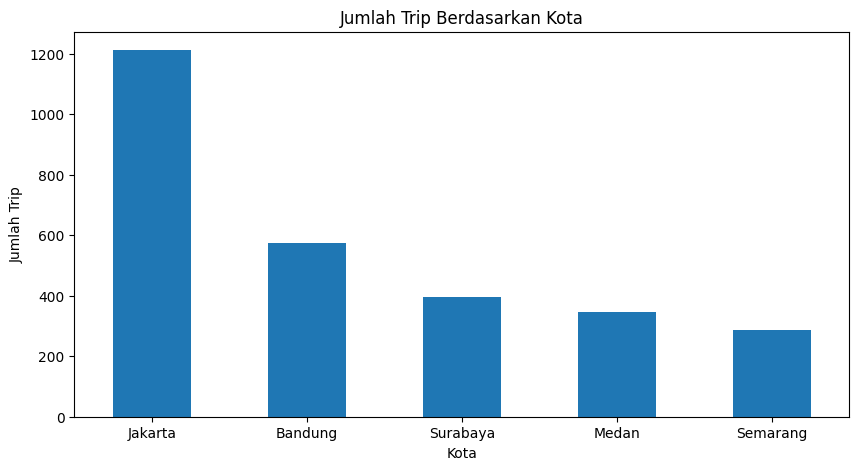

In [9]:
plt.figure(figsize=(10,5))

trip_city.plot(kind="bar")

plt.title("Jumlah Trip Berdasarkan Kota")
plt.xlabel("Kota")
plt.ylabel("Jumlah Trip")
plt.xticks(rotation=0)

plt.show()

###3. Descriptive — Demand berdasarkan jam

In [10]:
trip_hour = (
    df_completed
    .groupby("hour")["trip_id"]
    .count()
)

print(trip_hour)

hour
0      28
1      17
2      15
3      11
4      20
5      51
6     129
7     166
8     196
9     147
10    127
11    109
12    105
13    119
14    105
15    140
16    198
17    282
18    250
19    216
20    137
21    102
22     92
23     55
Name: trip_id, dtype: int64


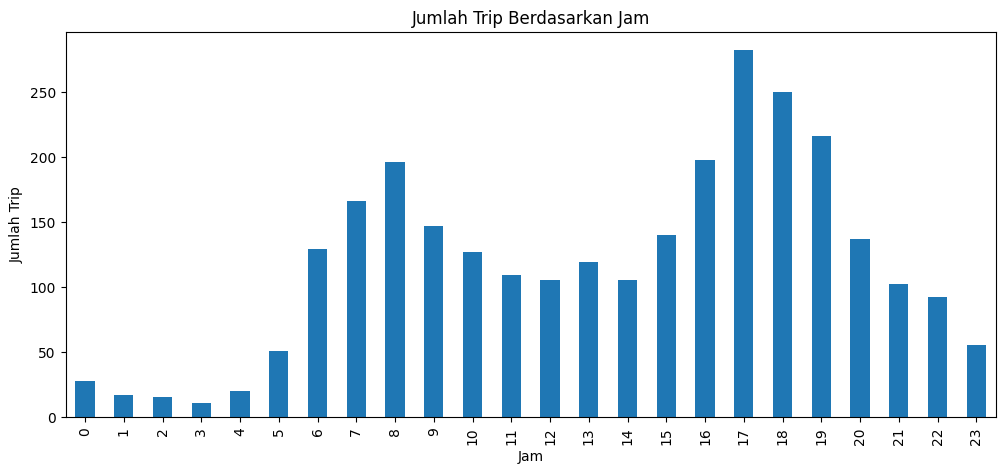

In [11]:
plt.figure(figsize=(12,5))

trip_hour.plot(kind="bar")

plt.title("Jumlah Trip Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Trip")

plt.show()

###4. Descriptive — Service

In [12]:
trip_service = (
    df_completed
    .groupby("service")["trip_id"]
    .count()
    .sort_values(ascending=False)
)

trip_service

,trip_id
service,
Bluebird,2061
Silver Bird,265
Bluebird Van,261
Golden Bird,230


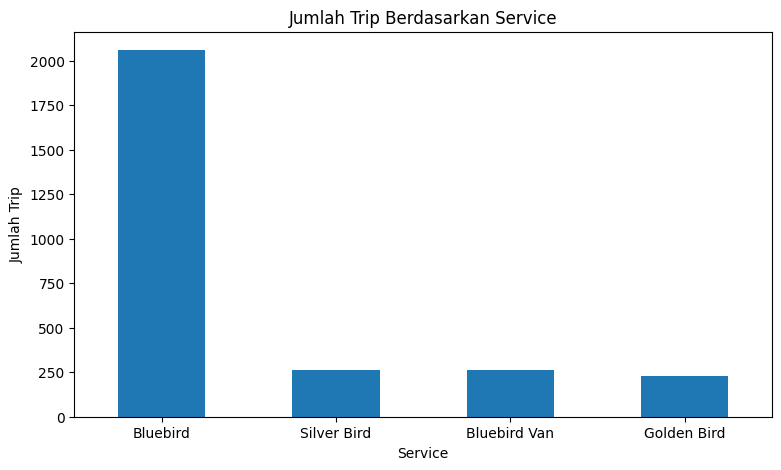

In [13]:
plt.figure(figsize=(9,5))

trip_service.plot(kind="bar")

plt.title("Jumlah Trip Berdasarkan Service")
plt.xlabel("Service")
plt.ylabel("Jumlah Trip")
plt.xticks(rotation=0)

plt.show()

#DIAGNOSTIC ANALYTICS
###1. Demand berdasarkan kota dan jam

In [16]:
city_hour = pd.pivot_table(
    df_completed,
    values="trip_id",
    index="city",
    columns="hour",
    aggfunc="count",
    fill_value=0
)

city_hour

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
city,,,,,,,,,,,,,,,,,,,,,
Bandung,6,4,2,0,4,13,29,39,38,24,...,19,25,57,66,50,39,26,19,20,10
Jakarta,14,8,5,7,11,19,60,66,72,68,...,30,62,86,120,110,107,60,45,39,19
Medan,1,2,2,2,1,6,13,22,28,24,...,25,9,20,27,30,27,17,13,14,10
Semarang,4,1,3,0,2,5,11,15,17,14,...,13,18,13,31,26,20,8,17,8,8
Surabaya,3,2,3,2,2,8,16,24,41,17,...,18,26,22,38,34,23,26,8,11,8


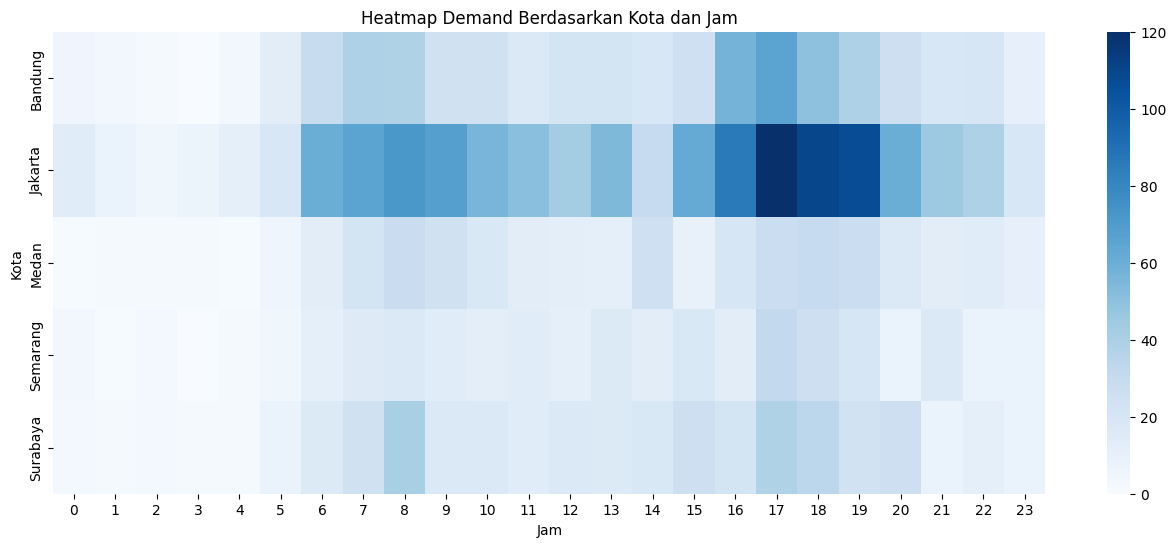

In [17]:
plt.figure(figsize=(16,6))

sns.heatmap(city_hour, cmap="Blues")

plt.title("Heatmap Demand Berdasarkan Kota dan Jam")
plt.xlabel("Jam")
plt.ylabel("Kota")

plt.show()

###2. Diagnostic — Duration vs Rating

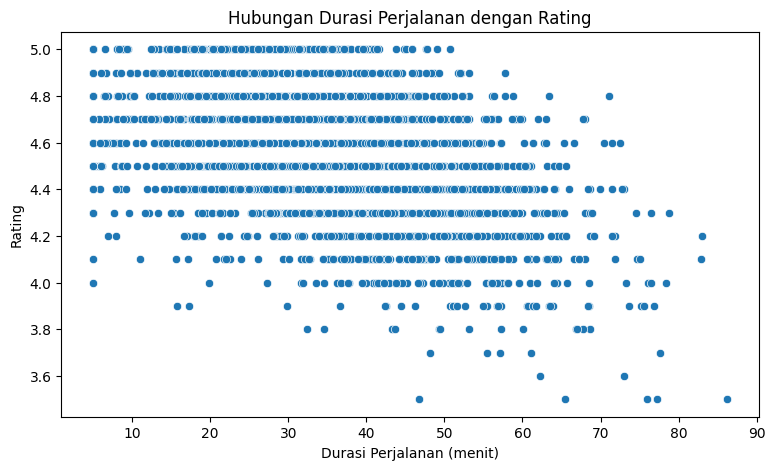

In [18]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df_completed,
    x="duration_minute",
    y="rating"
)

plt.title("Hubungan Durasi Perjalanan dengan Rating")
plt.xlabel("Durasi Perjalanan (menit)")
plt.ylabel("Rating")

plt.show()

###3. Membuat dataset agregasi untuk Predictive

In [19]:
agg = (
    df_completed
    .groupby(["date", "city", "hour"])
    .agg(
        demand=("trip_id", "count"),
        avg_fare=("fare", "mean"),
        avg_duration=("duration_minute", "mean"),
        avg_rating=("rating", "mean"),
        available_fleet=("available_fleet", "mean")
    )
    .reset_index()
)

agg.head()

,date,city,hour,demand,avg_fare,avg_duration,avg_rating,available_fleet
0,2025-01-01,Bandung,6,1,69690.0,43.60,4.3,255.0
1,2025-01-01,Bandung,8,1,10000.0,8.00,4.6,232.0
2,2025-01-01,Bandung,10,2,41963.0,39.55,4.6,341.0
3,2025-01-01,Bandung,14,1,27035.0,31.50,4.5,303.0
4,2025-01-01,Bandung,17,1,45048.0,37.70,4.6,247.0


###4. Membuat fitur predictive

In [20]:
agg["day_of_week"] = agg["date"].dt.dayofweek
agg["month"] = agg["date"].dt.month

agg["is_peak"] = agg["hour"].isin(
    [6, 7, 8, 9, 16, 17, 18, 19]
).astype(int)

agg.head()

,date,city,hour,demand,avg_fare,avg_duration,avg_rating,available_fleet,day_of_week,month,is_peak
0,2025-01-01,Bandung,6,1,69690.0,43.60,4.3,255.0,2,1,1
1,2025-01-01,Bandung,8,1,10000.0,8.00,4.6,232.0,2,1,1
2,2025-01-01,Bandung,10,2,41963.0,39.55,4.6,341.0,2,1,0
3,2025-01-01,Bandung,14,1,27035.0,31.50,4.5,303.0,2,1,0
4,2025-01-01,Bandung,17,1,45048.0,37.70,4.6,247.0,2,1,1


#PREDICTIVE ANALYTICS

###1. Menyiapkan X dan y

In [21]:
features = [
    "city",
    "hour",
    "day_of_week",
    "month",
    "is_peak",
    "available_fleet"
]

X = agg[features]
y = agg["demand"]

X = pd.get_dummies(
    X,
    columns=["city"],
    drop_first=False
)

print("Jumlah fitur:", X.shape[1])

Jumlah fitur: 10


###2. Membagi data training dan testing

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (1785, 10)
Testing data : (447, 10)


###3. Membuat Random Forest

In [23]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


###4. Menguji model

In [24]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== MODEL EVALUATION =====")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

===== MODEL EVALUATION =====
MAE : 0.380
R²  : 0.105


###5. Visualisasi Actual vs Prediction

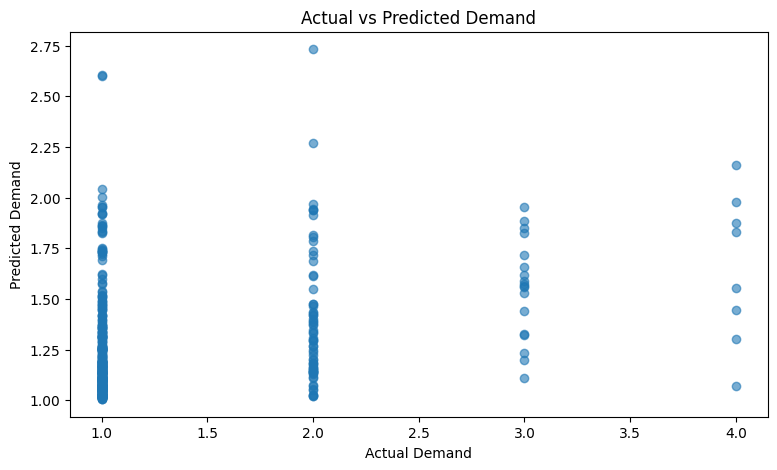

In [25]:
plt.figure(figsize=(9,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

###6. Memprediksi demand

In [26]:
future_data = pd.DataFrame({
    "city": ["Jakarta", "Bandung", "Surabaya", "Medan", "Semarang"],
    "hour": [17, 17, 17, 17, 17],
    "day_of_week": [0, 0, 0, 0, 0],
    "month": [4, 4, 4, 4, 4],
    "is_peak": [1, 1, 1, 1, 1],
    "available_fleet": [650, 300, 240, 200, 160]
})

future_encoded = pd.get_dummies(
    future_data,
    columns=["city"],
    drop_first=False
)

future_encoded = future_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

future_data["predicted_demand"] = model.predict(
    future_encoded
).round(2)

future_data

,city,hour,day_of_week,month,is_peak,available_fleet,predicted_demand
0,Jakarta,17,0,4,1,650,1.28
1,Bandung,17,0,4,1,300,1.03
2,Surabaya,17,0,4,1,240,1.30
3,Medan,17,0,4,1,200,1.23
4,Semarang,17,0,4,1,160,1.05


#PRESCRIPTIVE ANALYTICS

###1. Membuat threshold


In [27]:
city_threshold = (
    agg.groupby("city")["demand"]
    .quantile([0.25, 0.75])
    .unstack()
)

city_threshold.columns = [
    "low_threshold",
    "high_threshold"
]

city_threshold

,low_threshold,high_threshold
city,,
Bandung,1.0,1.0
Jakarta,1.0,2.0
Medan,1.0,1.0
Semarang,1.0,1.0
Surabaya,1.0,1.0


###2. Membuat rekomendasi

In [28]:
def recommendation(row):

    city = row["city"]
    demand = row["predicted_demand"]

    low = city_threshold.loc[city, "low_threshold"]
    high = city_threshold.loc[city, "high_threshold"]

    if demand >= high:
        return "Prioritaskan / tambah armada"

    elif demand <= low:
        return "Pertimbangkan redistribusi armada"

    else:
        return "Pertahankan armada"

In [31]:
future_data["recommendation"] = future_data.apply(
    recommendation,
    axis=1
)

future_data

,city,hour,day_of_week,month,is_peak,available_fleet,predicted_demand,recommendation
0,Jakarta,17,0,4,1,650,1.28,Pertahankan armada
1,Bandung,17,0,4,1,300,1.03,Prioritaskan / tambah armada
2,Surabaya,17,0,4,1,240,1.30,Prioritaskan / tambah armada
3,Medan,17,0,4,1,200,1.23,Prioritaskan / tambah armada
4,Semarang,17,0,4,1,160,1.05,Prioritaskan / tambah armada


In [32]:
# Export hasil predictive dan prescriptive
future_data.to_csv(
    "prediction_recommendation_results.csv",
    index=False
)

print("Hasil prediksi dan rekomendasi berhasil disimpan.")

Hasil prediksi dan rekomendasi berhasil disimpan.
